# Project 카메라 스티커앱 만들기
- 얼굴 검출 & 랜드마크 검출
- 스티커 적용

In [1]:
# 라이브러리 import
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

In [2]:
# 이미지 설정
my_image_path = os.path.join('images', 'image2.png')
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy()

## HOG detector 적용

In [3]:
# dlib의 hog detector
detector_hog = dlib.get_frontal_face_detector()

In [4]:
# img를 rgb로 변환 후 1회 업스케일링해서 detector 적용
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)

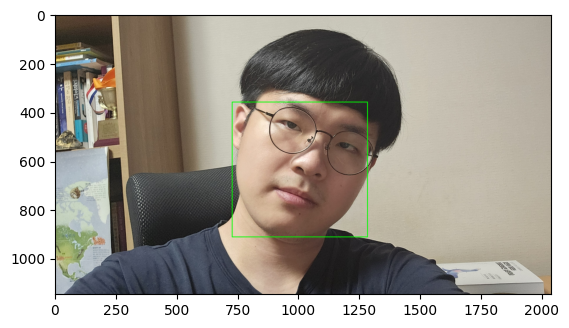

In [5]:
# detector 결과 확인
for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

## landmark 저장

In [6]:
# landmark 모델 불러오기
model_path = os.path.join('models', 'shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)

In [7]:
# 얼굴 영역 박스 마다 face landmark를 찾아내 좌표를 저장
list_landmarks = []
for dlib_rect in dlib_rects:
    # 모든 landmark의 위치정보를 points 변수에 저장
    points = landmark_predictor(img_rgb, dlib_rect)
    # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    # list_landmarks에 landmark 리스트를 저장
    list_landmarks.append(list_points)

In [8]:
# landmark 확인
for landmark in list_landmarks:
    for point in landmark:
        # cv2.circle: OpenCV의 원을 그리는 함수
        cv2.circle(img_show, point, 4, (0, 255, 255), -1)

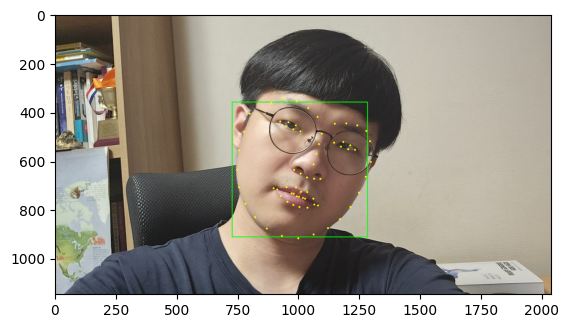

In [9]:
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()
img_save = img_show.copy()

## 스티커 적용

In [10]:
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    # 2번과 14번 가운데 위치로
    x = (landmark[2][0] + landmark[14][0]) // 2
    y = (landmark[2][1] + landmark[14][1]) // 2
    w = h = dlib_rect.width()

    # 2번과 14번으로 기울기 구하기
    dx = landmark[14][0] - landmark[2][0]
    dy = landmark[14][1] - landmark[2][1]
    angle = -np.degrees(np.arctan2(dy, dx))

    # 스티커 불러오기 & 크기 맞추기
    sticker_path = os.path.join('images', 'cat-whiskers.png')
    img_sticker = cv2.imread(sticker_path)
    img_sticker = cv2.resize(img_sticker, (w,h))

    # 기울기만큼 스티커도 기울이기
    rotation_matrix = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
    img_sticker = cv2.warpAffine(img_sticker, rotation_matrix, (w, h))

    # 위치 조정
    refined_x = x - w // 2
    refined_y = y - h // 2
    refined_x = max(0, min(refined_x, img_show.shape[1] - img_sticker.shape[1]))
    refined_y = max(0, min(refined_y, img_show.shape[0] - img_sticker.shape[0]))

    # 스티커 적용
    sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
    img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = np.where(img_sticker==255,sticker_area,img_sticker).astype(np.uint8)

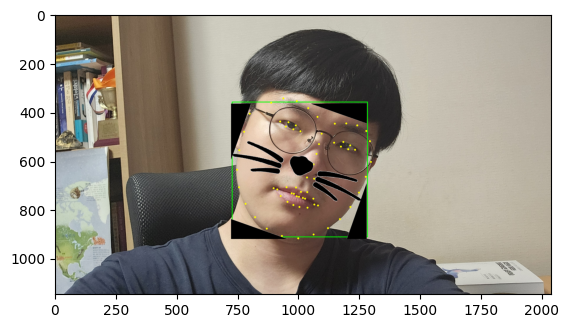

In [11]:
# 확인
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()
img_show = img_save.copy()

2번과 14번의 평균을 사용했지만 사진상에서 코의 위치와 달랐다   
- 축은 맞추고 위치는 비슷한 30번과 33번의 평균으로 수정
rotate하면서 sticker에서 빈부분을 검은색으로 채우고 붙이면서 검은 색이 덧붙여진것으로 보인다
- rotate후 빈부분을 흰색으로 메우기

In [12]:
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    # 30번과 33번 가운데 위치로
    x = (landmark[30][0] + landmark[33][0]) // 2
    y = (landmark[30][1] + landmark[33][1]) // 2
    w = h = dlib_rect.width()

    # 기울기는 동일
    dx = landmark[14][0] - landmark[2][0]
    dy = landmark[14][1] - landmark[2][1]
    angle = -np.degrees(np.arctan2(dy, dx))

    # 스티커 불러오기 & 크기 맞추기
    sticker_path = os.path.join('images', 'cat-whiskers.png')
    img_sticker = cv2.imread(sticker_path)
    img_sticker = cv2.resize(img_sticker, (w,h))

    # rotate하고 boderValue를 통해 흰색(255, 255, 255)로 매우기
    rotation_matrix = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
    img_sticker = cv2.warpAffine(img_sticker, rotation_matrix, (w, h), borderValue=(255, 255, 255))

    # 위치 조정
    refined_x = x - w // 2
    refined_y = y - h // 2
    refined_x = max(0, min(refined_x, img_show.shape[1] - img_sticker.shape[1]))
    refined_y = max(0, min(refined_y, img_show.shape[0] - img_sticker.shape[0]))

    # 스티커 적용
    sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
    img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = np.where(img_sticker==255,sticker_area,img_sticker).astype(np.uint8)

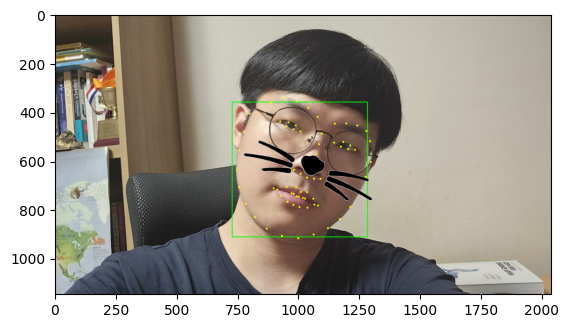

In [13]:
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

위치가 코끝으로 오고 검은 배경도 사라진 것을 확인할 수 있었다

## 테스트

In [14]:
# 위의 코드 종합 (이미지 테스트용 함수화)
def sticker_image(image_name):
    my_image_path = os.path.join('images', image_name)
    img_bgr = cv2.imread(my_image_path)
    img_show = img_bgr.copy()

    detector_hog = dlib.get_frontal_face_detector()
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    dlib_rects = detector_hog(img_rgb, 1)

    for dlib_rect in dlib_rects:
        l = dlib_rect.left()
        t = dlib_rect.top()
        r = dlib_rect.right()
        b = dlib_rect.bottom()

        cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

    model_path = os.path.join('models', 'shape_predictor_68_face_landmarks.dat')
    landmark_predictor = dlib.shape_predictor(model_path)

    list_landmarks = []
    for dlib_rect in dlib_rects:
        points = landmark_predictor(img_rgb, dlib_rect)
        list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        list_landmarks.append(list_points)

    for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
        x = (landmark[30][0] + landmark[33][0]) // 2
        y = (landmark[30][1] + landmark[33][1]) // 2
        w = h = dlib_rect.width()

        dx = landmark[14][0] - landmark[2][0]
        dy = landmark[14][1] - landmark[2][1]
        angle = -np.degrees(np.arctan2(dy, dx))

        sticker_path = os.path.join('images', 'cat-whiskers.png')
        img_sticker = cv2.imread(sticker_path)
        img_sticker = cv2.resize(img_sticker, (w,h))

        rotation_matrix = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
        img_sticker = cv2.warpAffine(img_sticker, rotation_matrix, (w, h), borderValue=(255, 255, 255))

        refined_x = x - w // 2
        refined_y = y - h // 2

        refined_x = max(0, min(refined_x, img_show.shape[1] - img_sticker.shape[1]))
        refined_y = max(0, min(refined_y, img_show.shape[0] - img_sticker.shape[0]))

        sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
        img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = np.where(img_sticker==255,sticker_area,img_sticker).astype(np.uint8)
        sticker_area = img_bgr[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
        img_bgr[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = np.where(img_sticker==255,sticker_area,img_sticker).astype(np.uint8)

        return img_bgr, img_show

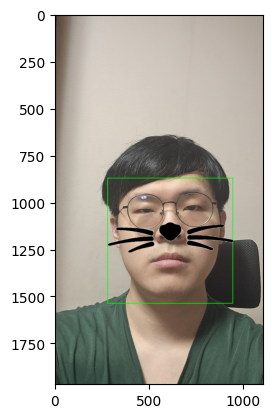

In [15]:
result = sticker_image("image1.png")
if result is None:
    print("검출 실패")
else:
    _, img_show = result
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.show()

정면은 문제가 없다

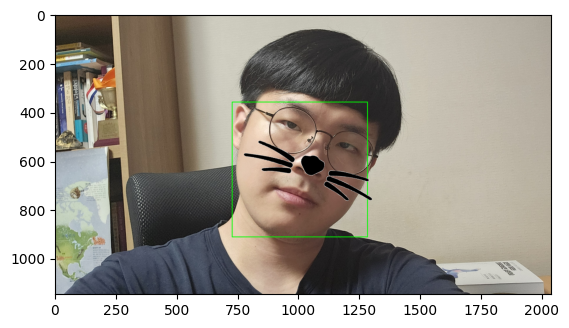

In [16]:
result = sticker_image("image2.png")
if result is None:
    print("검출 실패")
else:
    _, img_show = result
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.show()

기울여도 문제가 생기지 않는다

In [17]:
result = sticker_image("image3.png")
if result is None:
    print("검출 실패")
else:
    _, img_show = result
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.show()

검출 실패


측면은 detector가 얼굴을 찾지 못해 None을 반환한다

In [18]:
result = sticker_image("image4.jpg")
if result is None:
    print("검출 실패")
else:
    _, img_show = result
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.show()

검출 실패


어두운 경우 detector가 얼굴을 찾지 못해 None을 반환한다

## 최종 결과

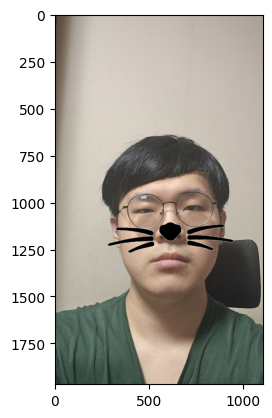

In [19]:
img_bgr, _ = sticker_image("image1.png")
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

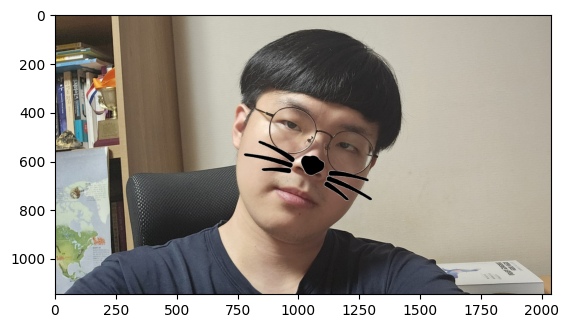

In [20]:
img_bgr, _ = sticker_image("image2.png")
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

## 회고
HOG detector의 특성상 정면 윤곽선 패턴에 강하기 때문에 측면이거나 윤곽선을 알아보기 힘든 밝기에선 얼굴을 검출하지 못했다.   
이는 detector의 특성을 찾아보며 예상했던바인데 스티커를 붙이는 과정에서 각도를 생각해 rotate를 했는데 검은 배경이 추가되어 당황스러웠다.   
하지만 where에서 흰색(sticker의 배경색)을 날렸는데 검은 색이 나온 것으로보아 rotate를 하고 남은 자리를 (0,0,0)으로 채운다는 사실을 알 수 있었다.   
위치를 잡는데 2번과 14번을 사용했었는데 요각이라던가 완전대칭이 아닌 점을 고려하지 못한 선택이였던 것같다.   